<h1 style="color: red;">PART 1 (Input the data and converting)</h1>

# Step 1 - Import Panda and read data (csv file)

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('C:/Users/Acer/Predictions/data_folder/blood_inventory_Aneg.csv')
print(data.dtypes)

Month    object
A-        int64
dtype: object


# Step 2 - Check for result, if object/string convert to datetime format

In [4]:
data['Month'] = pd.to_datetime(data['Month'], format='%m/%d/%Y')

# Step 3 - Set the data.set to index (Month)

In [5]:
data.set_index('Month', inplace=True, drop=False)

In [6]:
data = data.asfreq('MS')

# Step 4 - Confirm conversion by printing

In [7]:
print(data.dtypes)

Month    datetime64[ns]
A-                int64
dtype: object


<h1 style="color: red;">PART 2 (Visualizing the data)</h1>

# Step 1 - Use matplot and plot the data

In [8]:
import matplotlib.pyplot as plt

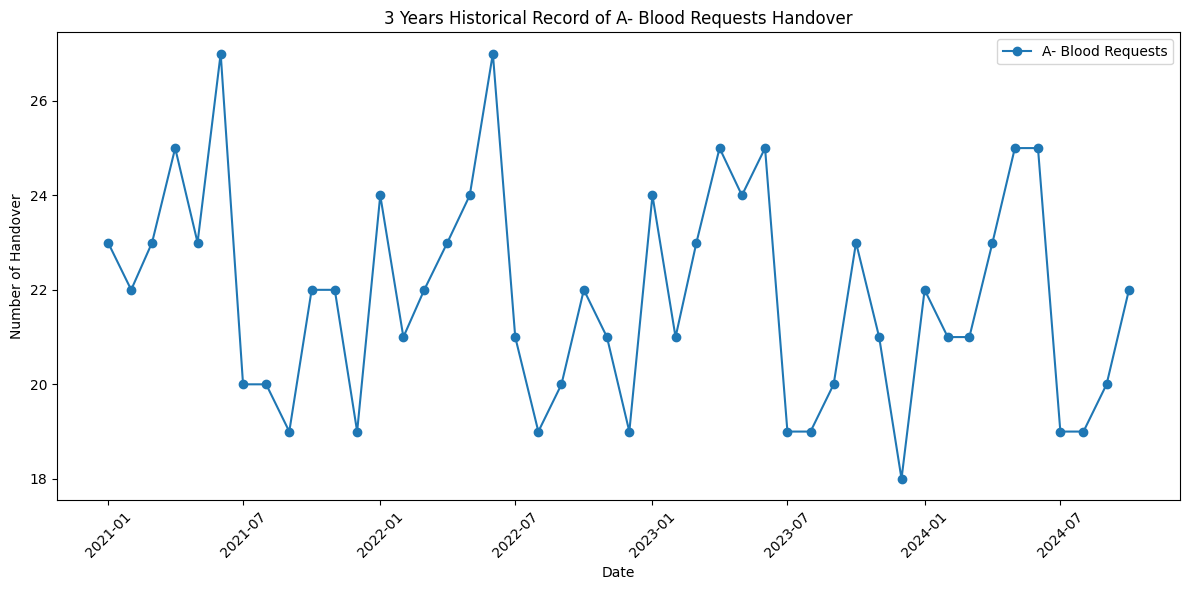

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['A-'], marker='o', label='A- Blood Requests')
plt.title('3 Years Historical Record of A- Blood Requests Handover')
plt.xlabel('Date')
plt.ylabel('Number of Handover')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()  # Adjust plot for better fit
plt.show()

<h1 style="color: red;">PART 3 (Choosing the right model of ARIMA)</h1>

# Method 1 - User plot_acf and plot_pacf (if the lags is not accepted adjust)

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

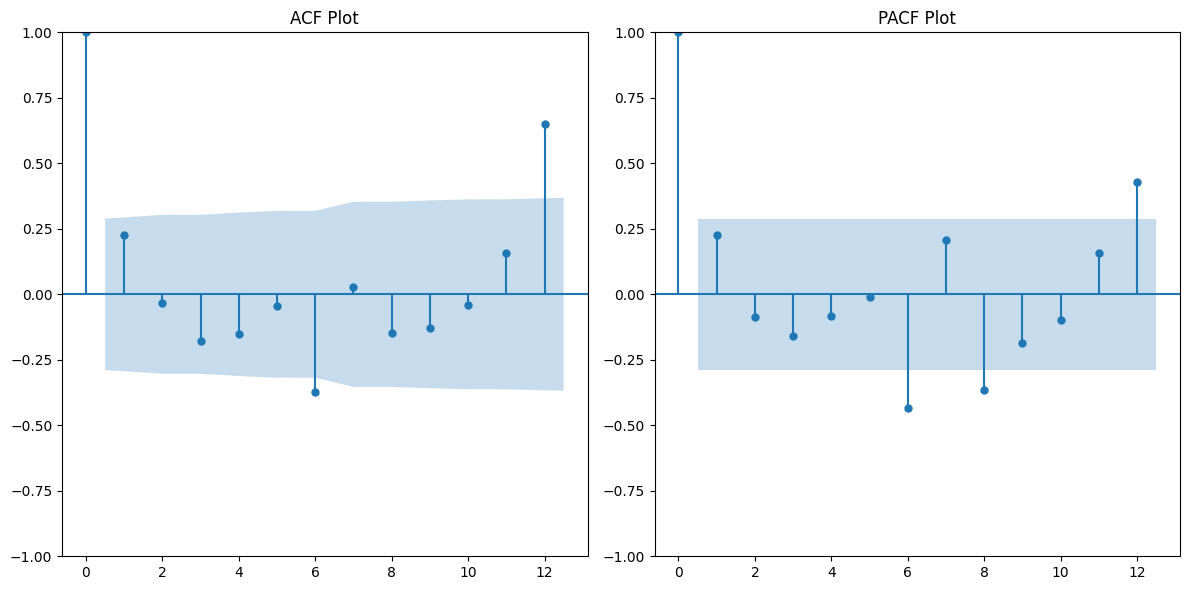

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF with fewer lags
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(data['A-'], ax=plt.gca(), lags=12)  # Adjust lags to 8
plt.title('ACF Plot')

plt.subplot(1, 2, 2)
plot_pacf(data['A-'], ax=plt.gca(), lags=12)  # Adjust lags to 8
plt.title('PACF Plot')

plt.tight_layout()
plt.show()


# Method 2 - Check for ADF test if the plot is non-stationary

In [12]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(data['A-'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'{key}: {value}')

# Check if the series is stationary
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: -1.971032859481338
p-value: 0.29941679149847755
Critical Values:
1%: -3.6327426647230316
5%: -2.9485102040816327
10%: -2.6130173469387756
The time series is not stationary.


# Step 1 - Fit proper ARIMA Model (SARIMA if Seasonal Data)

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define your parameters here (adjust them based on your analysis)
p = 1   # Auto-regressive order
d = 1   # Differencing order
q = 0   # Moving average order
P = 0   # Seasonal auto-regressive order
D = 1   # Seasonal differencing order
Q = 0   # Seasonal moving average order
S = 12  # Length of the seasonal cycle (e.g., 12 for monthly data)

# Fit the SARIMA model
model = SARIMAX(data['A-'], order=(p, d, q), seasonal_order=(P, D, Q, S))
results = model.fit()

# Print the model summary
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 A-   No. Observations:                   46
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                 -55.966
Date:                            Thu, 31 Oct 2024   AIC                            115.931
Time:                                    19:41:00   BIC                            118.924
Sample:                                01-01-2021   HQIC                           116.938
                                     - 10-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3282      0.201     -1.634      0.102      -0.722       0.065
sigma2         1.7341      0.477   

# Step 2 - Check for residuals (ensure that the results resembles white noise)

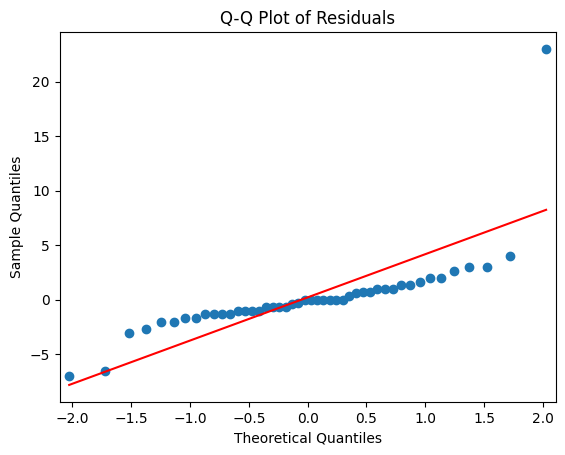

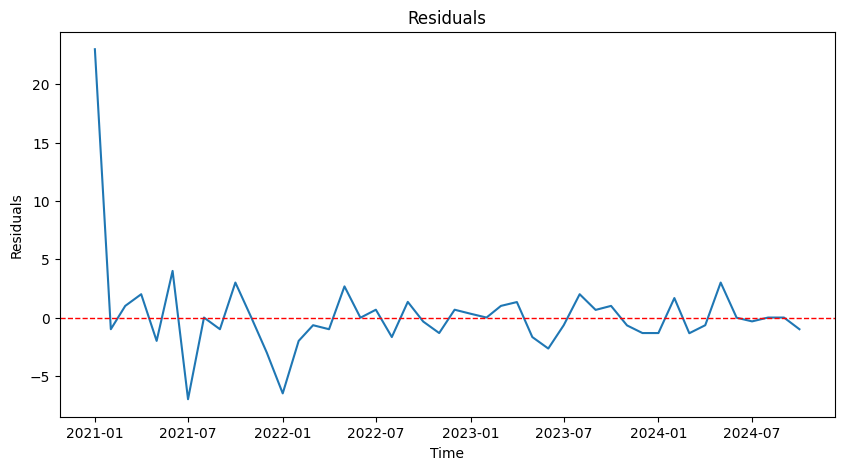

    lb_stat  lb_pvalue
1  0.099159   0.752841
The residuals do not show significant autocorrelation (white noise).


In [14]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Plot residuals
residuals = results.resid

# Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# Residuals Plot
plt.figure(figsize=(10, 5))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # Horizontal line at zero
plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.show()

# Perform Ljung-Box test
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[1], return_df=True)
print(lb_test)  # Check the structure of lb_test

# Access the p-value correctly
p_value = lb_test['lb_pvalue'].values[0]  # Use .values to get the numpy array
if p_value > 0.05:
    print("The residuals do not show significant autocorrelation (white noise).")
else:
    print("The residuals show significant autocorrelation (not white noise).")

<h1 style="color: red;">PART 4 (Forecasting Model)</h1>

            A-
Month         
2021-01-01  23
2021-02-01  22
2021-03-01  23
2021-04-01  25
2021-05-01  23
<MonthBegin>


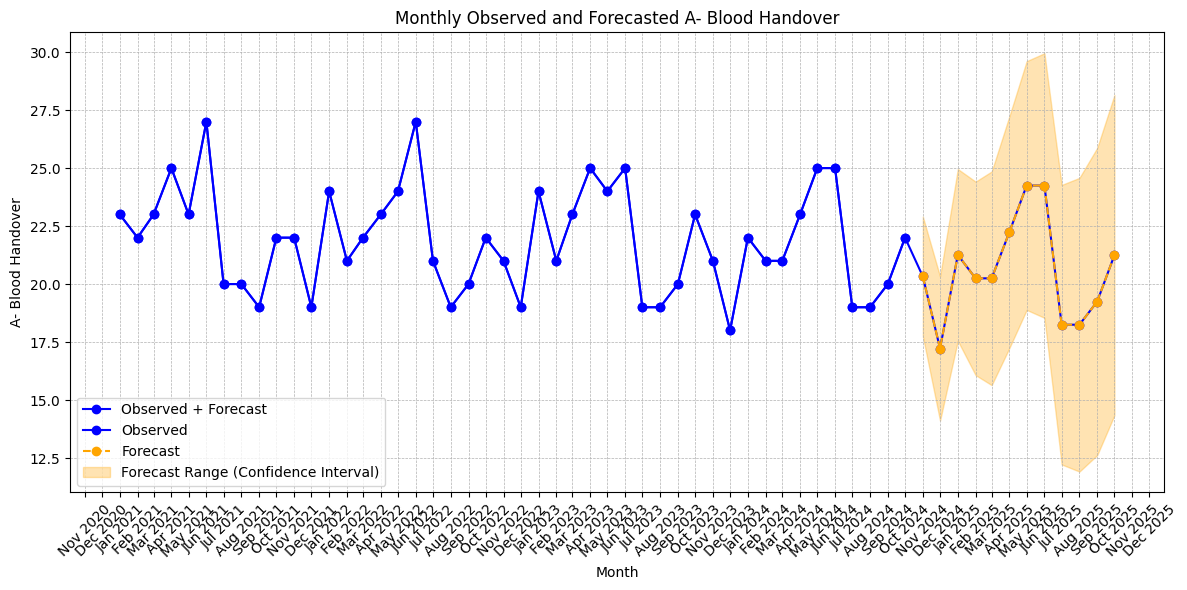

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Ensure this is imported
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Step 1: Load and prepare your historical data
data = pd.read_csv('C:/Users/Acer/Predictions/data_folder/blood_inventory_Aneg.csv', parse_dates=['Month'], index_col='Month')

# Set the frequency to start of the month
data = data.asfreq('MS')

# Check if data is loaded correctly
print(data.head())
print(data.index.freq)  # Should print the frequency

# Step 2: Fit your SARIMA model
p, d, q = 1, 1, 0
P, D, Q, S = 0, 1, 0, 12  # Example seasonal parameters
model = SARIMAX(data['A-'], order=(p, d, q), seasonal_order=(P, D, Q, S))
results = model.fit()

# Step 3: Generate forecasts
forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

# Create a DataFrame for the forecasted values
forecast_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_df.index = forecast_dates

# Step 4: Save the forecast to a file with explicit date column
forecast_df['Date'] = forecast_dates
forecast_df.set_index('Date', inplace=True)
forecast_df.to_csv('forecast_file_A-.csv')

# Step 5: Combine observed and forecasted data for plotting
combined_data = pd.concat([data['A-'], forecast_df['mean']])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(combined_data, label='Observed + Forecast', color='blue', linestyle='-', marker='o')
plt.plot(data['A-'], label='Observed', color='blue', linestyle='-', marker='o')
plt.plot(forecast_df['mean'], label='Forecast', color='orange', linestyle='--', marker='o')

# Fill confidence interval for the forecasted period
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], 
                 color='orange', alpha=0.3, label='Forecast Range (Confidence Interval)')

# Format x-axis for monthly labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Add title, labels, grid, and legend
plt.title('Monthly Observed and Forecasted A- Blood Handover')
plt.xlabel('Month')
plt.ylabel('A- Blood Handover')
plt.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Step 3 - Create a csv file of the prediction

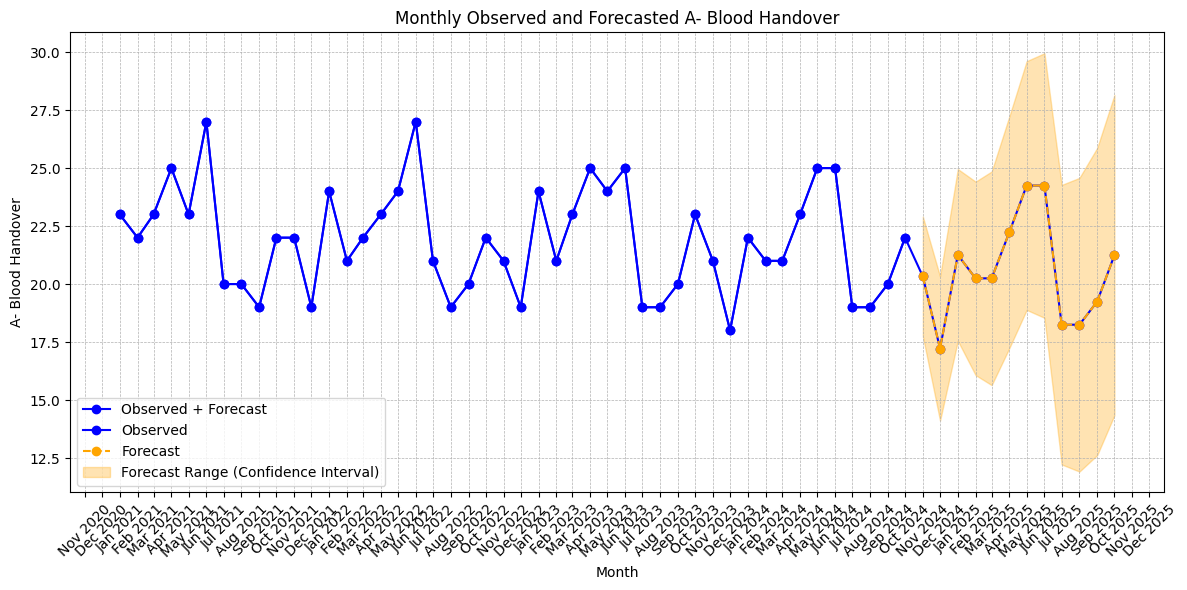

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import datetime

# Step 1: Load and prepare your historical data
data = pd.read_csv('C:/Users/Acer/Predictions/data_folder/blood_inventory_Aneg.csv', parse_dates=['Month'], index_col='Month')
data = data.asfreq('MS')  # Set the frequency to the start of each month

# Step 2: Fit your SARIMA model
p, d, q = 1, 1, 0
P, D, Q, S = 0, 1, 0, 12
model = SARIMAX(data['A-'], order=(p, d, q), seasonal_order=(P, D, Q, S))
results = model.fit()

# Step 3: Determine the forecast start date
current_date = pd.Timestamp(datetime.now().strftime('%Y-%m-01'))  # Start of the current month
forecast_start_date = data.index[-1] + pd.DateOffset(months=1)  # Month following the last date in data
start_date = max(current_date, forecast_start_date)  # Use the later of the two dates

# Step 4: Generate forecast dates and forecasts
forecast_steps = 12
forecast_dates = pd.date_range(start=start_date, periods=forecast_steps, freq='MS')
forecast = results.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()
forecast_df.index = forecast_dates

# Step 5: Save the forecast to a file
forecast_df['Date'] = forecast_dates
forecast_df.set_index('Date', inplace=True)
forecast_df.to_csv('forecast_file_A-.csv')

# Step 6: Combine observed and forecasted data for plotting
combined_data = pd.concat([data['A-'], forecast_df['mean']])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(combined_data, label='Observed + Forecast', color='blue', linestyle='-', marker='o')
plt.plot(data['A-'], label='Observed', color='blue', linestyle='-', marker='o')
plt.plot(forecast_df['mean'], label='Forecast', color='orange', linestyle='--', marker='o')

# Fill confidence interval for the forecasted period
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], 
                 color='orange', alpha=0.3, label='Forecast Range (Confidence Interval)')

# Format x-axis for monthly labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Add title, labels, grid, and legend
plt.title('Monthly Observed and Forecasted A- Blood Handover')
plt.xlabel('Month')
plt.ylabel('A- Blood Handover')
plt.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Combined result (A+ and A-)

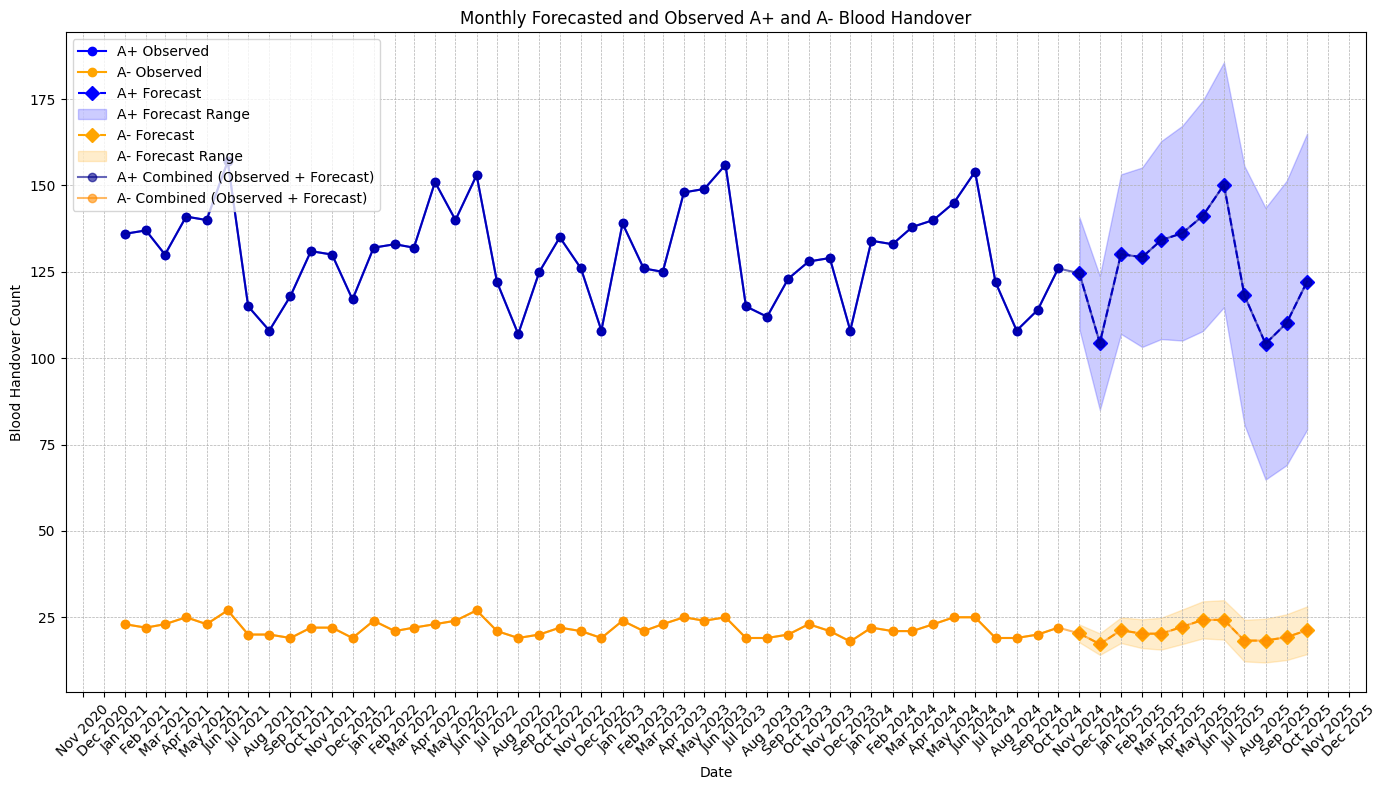

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load forecast and observed data
O_plus_forecast = pd.read_csv('forecast_file_A+.csv', parse_dates=['Date'], index_col='Date')
O_minus_forecast = pd.read_csv('forecast_file_A-.csv', parse_dates=['Date'], index_col='Date')
O_plus_observed = pd.read_csv('C:/Users/Acer/Predictions/data_folder/blood_inventory_Apos.csv', parse_dates=['Month'], index_col='Month')
O_minus_observed = pd.read_csv('C:/Users/Acer/Predictions/data_folder/blood_inventory_Aneg.csv', parse_dates=['Month'], index_col='Month')

# Rename columns for clarity
O_plus_observed = O_plus_observed.rename(columns={'A+': 'Observed_A_plus'})
O_minus_observed = O_minus_observed.rename(columns={'A-': 'Observed_A_minus'})

# Combine the forecast datasets
combined_forecast = pd.merge(O_plus_forecast[['mean', 'mean_ci_lower', 'mean_ci_upper']], 
                             O_minus_forecast[['mean', 'mean_ci_lower', 'mean_ci_upper']], 
                             left_index=True, right_index=True, suffixes=('_A_plus', '_A_minus'))

# Combine observed data with forecast data
combined_data = pd.merge(combined_forecast, O_plus_observed[['Observed_A_plus']], left_index=True, right_index=True, how='outer')
combined_data = pd.merge(combined_data, O_minus_observed[['Observed_A_minus']], left_index=True, right_index=True, how='outer')

# Concatenate observed and forecast data for combined series
combined_data['Combined_A_plus'] = combined_data['Observed_A_plus'].combine_first(combined_data['mean_A_plus'])
combined_data['Combined_A_minus'] = combined_data['Observed_A_minus'].combine_first(combined_data['mean_A_minus'])

# Save the combined data to a CSV file
combined_data.to_csv('combined_forecast_file_A.csv', index=True)

# Plotting
plt.figure(figsize=(14, 8))

# Plot observed data
plt.plot(combined_data.index, combined_data['Observed_A_plus'], label='A+ Observed', color='blue', linestyle='-', marker='o')
plt.plot(combined_data.index, combined_data['Observed_A_minus'], label='A- Observed', color='orange', linestyle='-', marker='o')

# Plot forecasted data with confidence intervals
plt.plot(combined_data.index, combined_data['mean_A_plus'], label='A+ Forecast', color='blue', linestyle='--', marker='D', markersize=7)
plt.fill_between(combined_data.index, combined_data['mean_ci_lower_A_plus'], combined_data['mean_ci_upper_A_plus'], 
                 color='blue', alpha=0.2, label='A+ Forecast Range')
plt.plot(combined_data.index, combined_data['mean_A_minus'], label='A- Forecast', color='orange', linestyle='--', marker='D', markersize=7)
plt.fill_between(combined_data.index, combined_data['mean_ci_lower_A_minus'], combined_data['mean_ci_upper_A_minus'], 
                 color='orange', alpha=0.2, label='A- Forecast Range')

# Plot combined (observed + forecast)
plt.plot(combined_data.index, combined_data['Combined_A_plus'], label='A+ Combined (Observed + Forecast)', color='darkblue', linestyle='-', marker='o', alpha=0.6)
plt.plot(combined_data.index, combined_data['Combined_A_minus'], label='A- Combined (Observed + Forecast)', color='darkorange', linestyle='-', marker='o', alpha=0.6)

# Format x-axis to show only month-year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)  # Rotate dates for readability

# Add title, labels, grid, and legend
plt.title('Monthly Forecasted and Observed A+ and A- Blood Handover')
plt.xlabel('Date')
plt.ylabel('Blood Handover Count')
plt.grid(visible=True, which='major', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()